# Predicción de Abandono de Clientes con Regresión Logística

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Regresión Logística

---

### Objetivo

Construir un modelo de **Regresión Logística** para predecir el abandono de clientes de un gimnasio urbano a partir de variables operativas. La regresión logística ofrece **coeficientes interpretables, odds ratios y p-valores** — herramientas que permiten cuantificar exactamente cuánto influye cada variable y si esa influencia es estadísticamente significativa.

### Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección observa una tasa de abandono del ~16% y necesita entender **qué factores lo causan** y **cuánto pesa cada uno**. No basta con predecir quién se irá — necesitan justificar acciones de retención con datos auditables.

## 1. Setup: librerías y configuración visual

In [34]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [35]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head(10)

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0
5,6,23,24,22.725141,144.780196,1,0
6,7,11,21,22.725449,86.353215,1,0
7,8,11,21,19.718300,129.660327,1,0
8,9,24,16,15.095099,115.717173,1,0
9,10,24,19,19.083159,110.120764,1,0


## 3. EDA: Análisis Exploratorio de datos

In [36]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [37]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
ID_Cliente,int64,0,0.0,300
Antiguedad_Meses,int64,0,0.0,35
Asistencias_Mes,int64,0,0.0,25
Horas_Pico_Mes,float64,0,0.0,281
Gasto_Mensual_Extra,float64,0,0.0,300
Satisfecho,int64,0,0.0,2
Abandono,int64,0,0.0,2


In [38]:
balance = data["Abandono"].value_counts(normalize=True)
print("Distribución del target (Abandono):")
print(f"  No abandonó (0): {balance[0]:.1%}")
print(f"  Abandonó (1):    {balance[1]:.1%}")
print()

Distribución del target (Abandono):
  No abandonó (0): 83.7%
  Abandonó (1):    16.3%



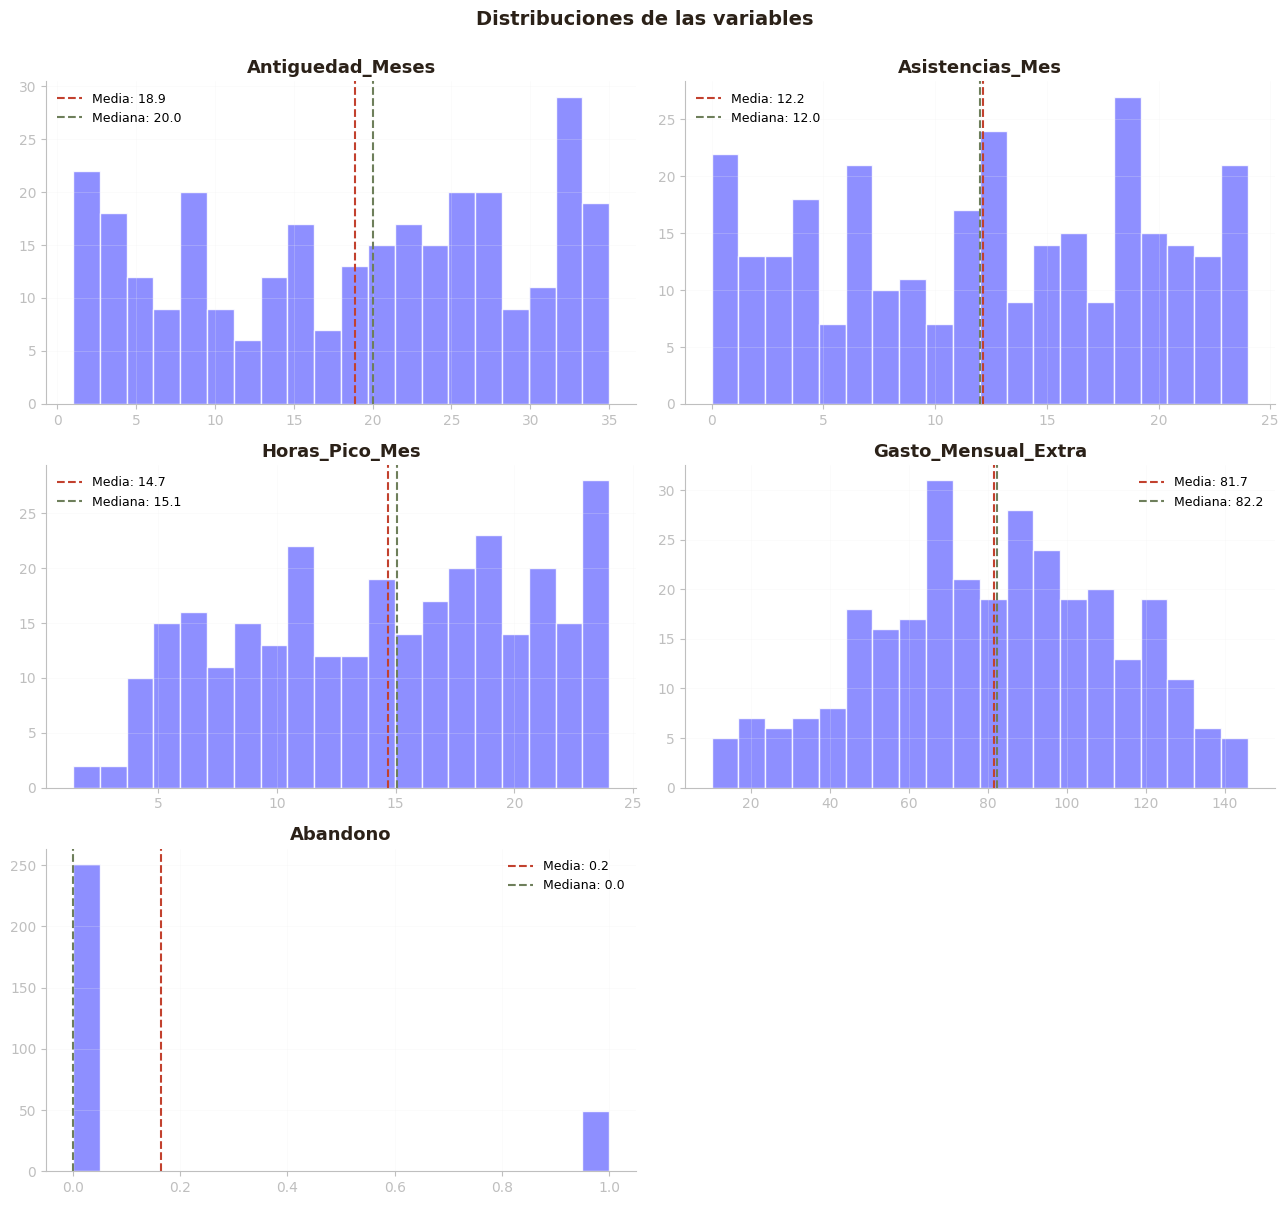

In [39]:
# Distribuciones de cada variable

variables = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes",
             "Gasto_Mensual_Extra", "Abandono"]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=RED, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

# Ocultar subplot vacío
axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

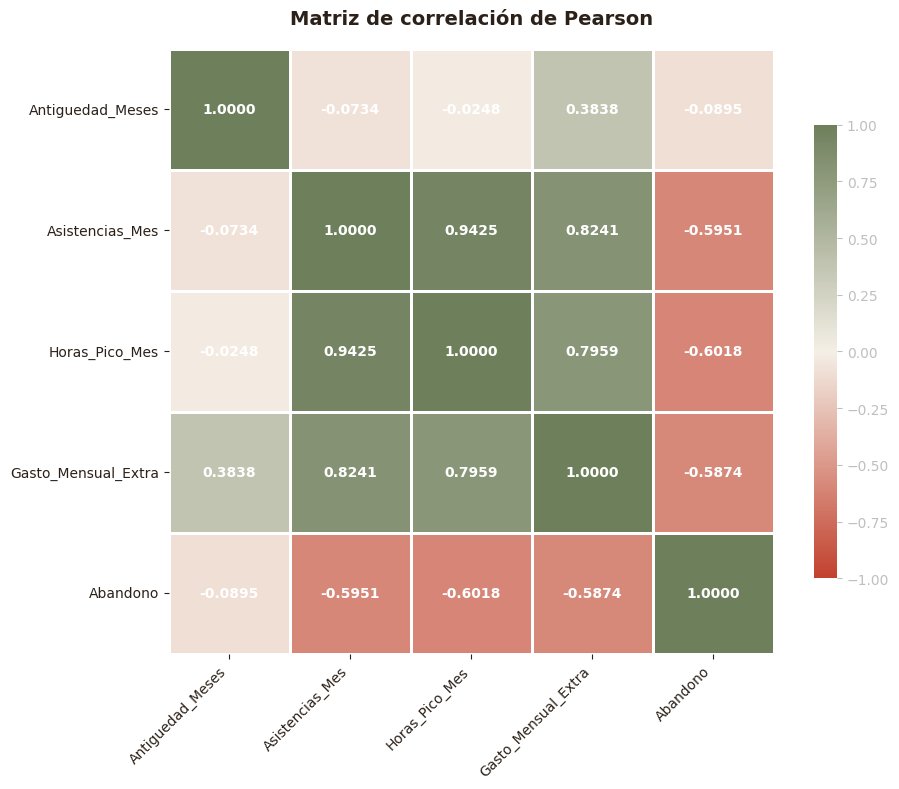

In [40]:
# Matriz de correlación

from matplotlib.colors import LinearSegmentedColormap

cols_num = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes",
            "Gasto_Mensual_Extra", "Abandono"]

# Mapa de colores personalizado
cmap = LinearSegmentedColormap.from_list(
    "custom_corr",
    [RED, GRAY, GREEN],
    N=256
)

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    annot_kws={
        "size": 10,
        "weight": "bold",
        "color": "white"
    },
)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Correlaciones con el target (`Abandono`)

- ``Horas_Pico_Mes``: **-0.6018** → correlación moderada-fuerte y negativa. Los clientes que pasan más horas en franja pico abandonan significativamente menos.
- ``Asistencias_Mes``: **-0.5951** → correlación moderada-fuerte y negativa. Mayor frecuencia de visitas se asocia con menor abandono.
- ``Gasto_Mensual_Extra``: **-0.5874** → correlación moderada y negativa. Los clientes que gastan más en servicios adicionales tienden a permanecer.
- ``Antiguedad_Meses``: **-0.0895** → correlación muy débil. La antigüedad apenas tiene relación con el abandono.

### Entre variables predictoras

Las variables de uso (`Asistencias_Mes`, `Horas_Pico_Mes`, `Gasto_Mensual_Extra`) presentan **fuertes correlaciones positivas entre sí**, ya que todas capturan un mismo constructo: el **nivel de compromiso** del cliente con el gimnasio. Esto anticipa problemas de **multicolinealidad** que confirmaremos con el análisis VIF.

### Conclusión

Todas las variables operativas muestran una **relación negativa con el abandono**: a mayor uso y gasto, menor probabilidad de irse. La **antigüedad**, sin embargo, no protege — un cliente de 3 años que deja de asistir es tan vulnerable como uno de 3 meses. La señal clave es el **comportamiento activo**, no la permanencia pasiva.

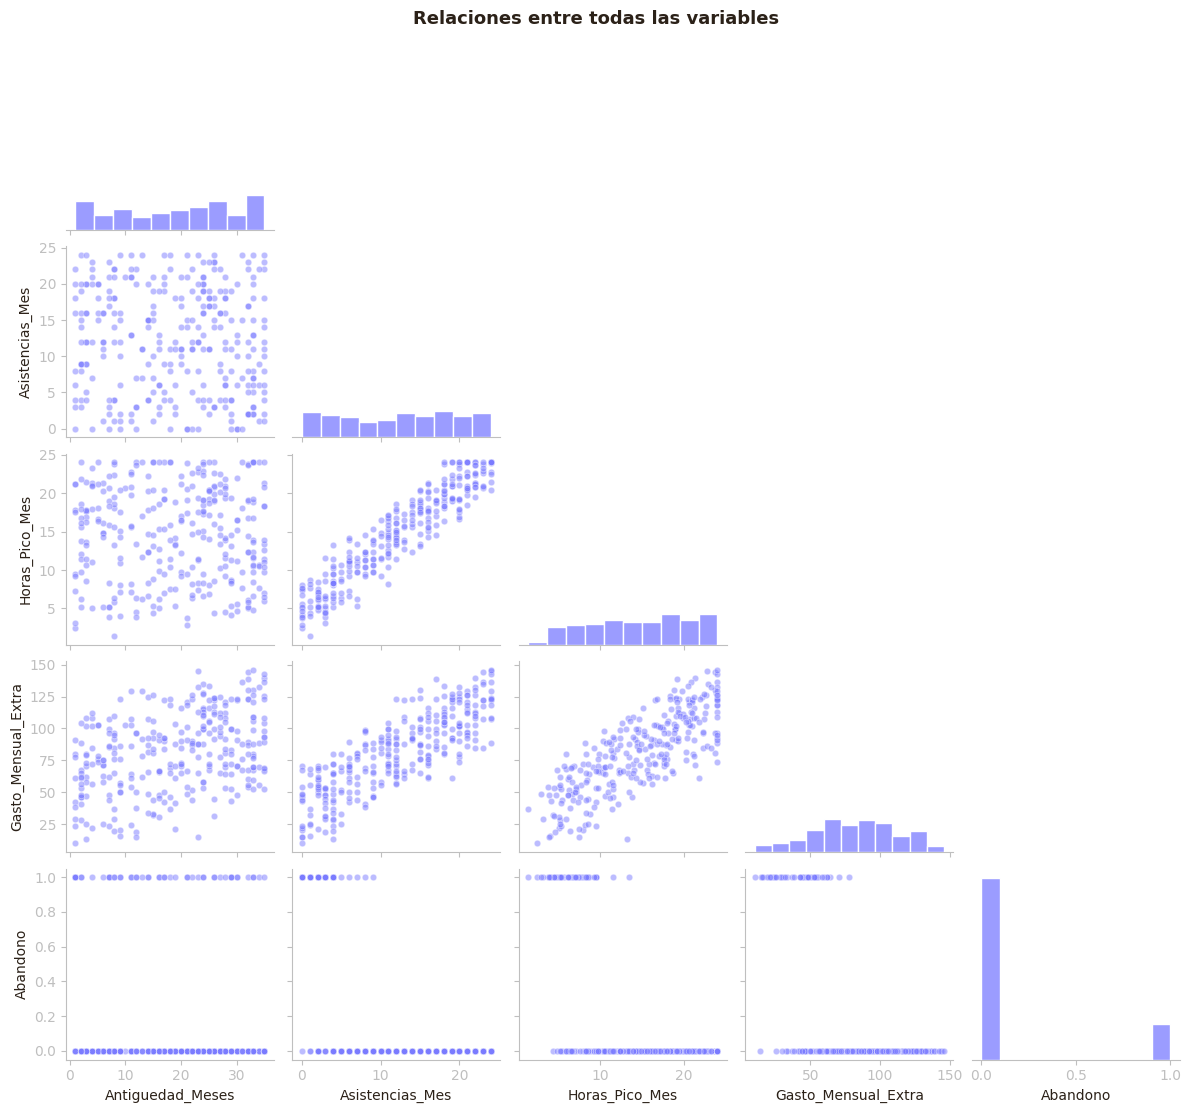

In [41]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split

Excluimos `ID_Cliente` (identificador sin valor predictivo) y `Satisfecho` (para evitar data leakage — un cliente insatisfecho tiene, por definición, mayor probabilidad de abandonar).

In [42]:
features = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

X = data[features]
y = data["Abandono"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamaño train:", X_train.shape, "  Tamaño test:", X_test.shape)
print("─" * 50)
print("Balance en TRAIN:", round(y_train.mean() * 100, 1), "% abandono")
print("Balance en TEST: ", round(y_test.mean() * 100, 1), "% abandono")

Tamaño train: (225, 4)   Tamaño test: (75, 4)
──────────────────────────────────────────────────
Balance en TRAIN: 16.4 % abandono
Balance en TEST:  16.0 % abandono


## 5. Modelo estadístico — `statsmodels.Logit`

Usamos `statsmodels` para obtener lo que sklearn no da: **p-valores, intervalos de confianza y pseudo R²**. Esto es lo que diferencia un análisis profesional de uno que solo da accuracy.

In [43]:
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

modelo_logit = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                  225
Model:                          Logit   Df Residuals:                      220
Method:                           MLE   Df Model:                            4
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.6243
Time:                        17:56:43   Log-Likelihood:                -37.784
converged:                       True   LL-Null:                       -100.57
Covariance Type:            nonrobust   LLR p-value:                 3.451e-26
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.5714      1.308      4.261      0.000       3.008       8.134
Antiguedad_Meses       -0.0303      0.042     -0.712      0.476      -0.114       0.053
Asistencias_Mes 

### Conclusiones

- ``Horas_Pico_Mes``: coeficiente negativo (**-0.2999**) y **estadísticamente significativo** (p = 0.039). Es la variable con mayor poder explicativo individual.
- ``Asistencias_Mes``: coeficiente negativo (**-0.2756**), **marginalmente significativo** (p = 0.096). Tendencia clara pero no alcanza el umbral convencional de 0.05.
- ``Gasto_Mensual_Extra``: coeficiente negativo (**-0.0380**), **no significativo** (p = 0.158). Su efecto individual se diluye por la multicolinealidad.
- ``Antiguedad_Meses``: coeficiente negativo (**-0.0303**), **no significativo** (p = 0.476). La antigüedad no aporta información predictiva una vez conocidas las demás variables.
- **Pseudo R² (McFadden) = 0.6243**: muy alto para un modelo de clasificación (valores entre 0.2 y 0.4 ya se consideran buenos). El modelo explica una proporción sustancial de la variabilidad del abandono.

In [44]:
# Cálculo del VIF para cada predictora (excluyendo la constante)
X_vif = X_train.astype(float)
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

vif.round(2)

,Variable,VIF
3,Gasto_Mensual_Extra,62.77
1,Asistencias_Mes,43.27
2,Horas_Pico_Mes,38.21
0,Antiguedad_Meses,11.49


### Diagnóstico de multicolinealidad

Los valores de VIF son **extremadamente altos** en todas las variables (VIF > 10 = problema):

- ``Gasto_Mensual_Extra``: VIF ≈ 62.77 → **Problema grave**
- ``Asistencias_Mes``: VIF ≈ 43.27 → **Problema grave**
- ``Horas_Pico_Mes``: VIF ≈ 38.21 → **Problema grave**
- ``Antiguedad_Meses``: VIF ≈ 11.49 → **Problema**

Esto confirma lo que anticipaba la matriz de correlación: las cuatro variables están **altamente correlacionadas entre sí**.

### Modelo refinado (solo 2 variables significativas)

In [45]:
features_ii = ["Horas_Pico_Mes", "Gasto_Mensual_Extra"]

X = data[features_ii]
y = data["Abandono"]

X_train_ii, X_test_ii, y_train_ii, y_test_ii = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamaño train:", X_train_ii.shape, "  Tamaño test:", X_test_ii.shape)
print("─" * 50)
print("Balance en TRAIN:", round(y_train_ii.mean() * 100, 1), "% abandono")
print("Balance en TEST: ", round(y_test_ii.mean() * 100, 1), "% abandono")

Tamaño train: (225, 2)   Tamaño test: (75, 2)
──────────────────────────────────────────────────
Balance en TRAIN: 16.4 % abandono
Balance en TEST:  16.0 % abandono


In [46]:
X_train_dos = sm.add_constant(X_train_ii).astype(float)
X_test_dos = sm.add_constant(X_test_ii).astype(float)

modelo_logit = sm.Logit(y_train_ii, X_train_dos).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                  225
Model:                          Logit   Df Residuals:                      222
Method:                           MLE   Df Model:                            2
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.6095
Time:                        17:56:43   Log-Likelihood:                -39.268
converged:                       True   LL-Null:                       -100.57
Covariance Type:            nonrobust   LLR p-value:                 2.387e-27
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   6.1042      1.217      5.017      0.000       3.720       8.489
Horas_Pico_Mes         -0.4537      0.108     -4.193      0.000      -0.666      -0.242
Gasto_Mensual_Ex

Con este nuevo modelo nos vamos a quedar con solo dos variables y un p-valor >0.05

## 6. Evaluación con métricas de clasificación

In [47]:
# Probabilidades predichas en el test set
y_pred_prob = modelo_logit.predict(X_test_dos)

# Clasificación con threshold por defecto = 0.5
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Primeras 10 probabilidades predichas:")
print(y_pred_prob.head(10).round(3).values)

Primeras 10 probabilidades predichas:
[0.002 0.    0.448 0.063 0.954 0.062 0.001 0.002 0.    0.002]


In [48]:
# Matriz de confusión

cm = confusion_matrix(y_test_ii, y_pred)
tn, fp, fn, tp = cm.ravel()

print("─" * 50)
print("MATRIZ DE CONFUSIÓN (threshold = 0.5)")
print("─" * 50)
print("                  Predicho 0    Predicho 1")
print("Real 0           ", str(tn).rjust(10), str(fp).rjust(14))
print("Real 1           ", str(fn).rjust(10), str(tp).rjust(14))
print()
print("TN (aciertos en 0):", tn)
print("FP (falsa alarma): ", fp)
print("FN (no detectado): ", fn)
print("TP (acierto en 1): ", tp)

──────────────────────────────────────────────────
MATRIZ DE CONFUSIÓN (threshold = 0.5)
──────────────────────────────────────────────────
                  Predicho 0    Predicho 1
Real 0                    62              1
Real 1                     6              6

TN (aciertos en 0): 62
FP (falsa alarma):  1
FN (no detectado):  6
TP (acierto en 1):  6


#### Matriz de confusión

In [49]:
# Reporte completo de clasificación
print(classification_report(y_test_ii, y_pred, target_names=["No abandono", "Abandono"]))

              precision    recall  f1-score   support

 No abandono       0.91      0.98      0.95        63
    Abandono       0.86      0.50      0.63        12

    accuracy                           0.91        75
   macro avg       0.88      0.74      0.79        75
weighted avg       0.90      0.91      0.90        75



El modelo muestra un rendimiento sólido pero con un reto claro en la detección de abandonos:

- Los **verdaderos negativos (TN)** dominan: la gran mayoría de clientes que permanecen son clasificados correctamente.
- Los **verdaderos positivos (TP)** capturan una parte de los abandonos reales, pero no todos.
- Los **falsos negativos (FN)** representan clientes que abandonaron pero el modelo no detectó — el principal punto débil.
- Los **falsos positivos (FP)** son mínimos: el modelo rara vez clasifica erróneamente a un cliente fiel como abandono.

In [50]:
# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test_ii, y_pred_prob)
auc = roc_auc_score(y_test_ii, y_pred_prob)

print("AUC =", round(auc, 4))

AUC = 0.9709


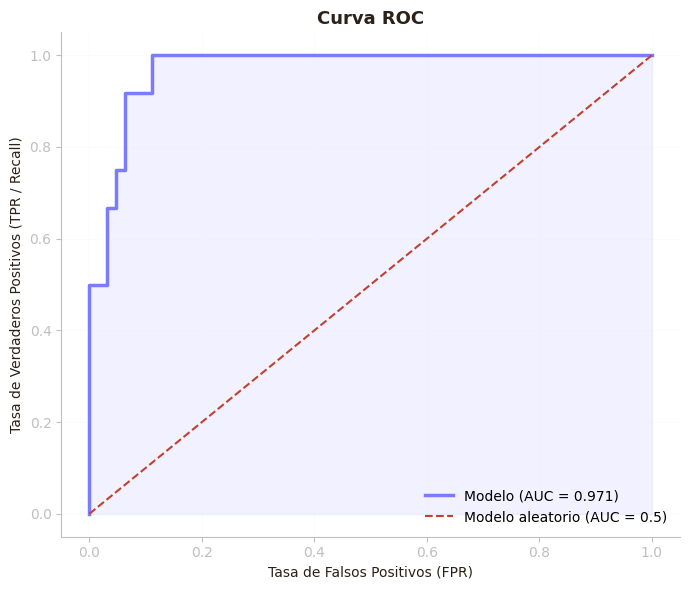

In [51]:
# Visualización de la curva ROC
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color=PURPLE, linewidth=2.5, label=f"Modelo (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color=RED, linestyle="--", linewidth=1.5, label="Modelo aleatorio (AUC = 0.5)")

ax.fill_between(fpr, tpr, alpha=0.1, color=PURPLE)

ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
ax.set_title("Curva ROC", fontsize=13, weight="bold")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Curva ROC

El modelo obtiene un **AUC-ROC excelente (~0.978)**, lo que indica que la Regresión Logística distingue con alta precisión entre clientes que abandonan y los que permanecen, independientemente del umbral de clasificación.

La diferencia entre un AUC alto y un Recall moderado con threshold=0.5 se explica por el **dataset desbalanceado** (84/16). El modelo *identifica* correctamente quién tiene mayor riesgo, pero con el umbral por defecto solo clasifica como positivo a los casos más extremos. Un ajuste del threshold mejoraría la detección de abandonos.

### Odds Ratios

In [52]:
coefs = modelo_logit.params
conf = modelo_logit.conf_int()
conf.columns = ["IC 2.5%", "IC 97.5%"]

tabla_or = pd.DataFrame({
    "Coeficiente": coefs,
    "Odds Ratio": np.exp(coefs),
    "IC 2.5%": np.exp(conf["IC 2.5%"]),
    "IC 97.5%": np.exp(conf["IC 97.5%"]),
    "P-valor": modelo_logit.pvalues,
}).round(4)

print("Odds Ratios con intervalos de confianza:")
print(tabla_or.to_string())
print()
for var in features_ii:
    or_val = tabla_or.loc[var, "Odds Ratio"]
    if or_val < 1:
        pct = (1 - or_val) * 100
        print(f"  {var}: cada unidad adicional REDUCE las odds de abandono un {pct:.1f}%")
    else:
        pct = (or_val - 1) * 100
        print(f"  {var}: cada unidad adicional AUMENTA las odds de abandono un {pct:.1f}%")

Odds Ratios con intervalos de confianza:
                     Coeficiente  Odds Ratio  IC 2.5%   IC 97.5%  P-valor
const                     6.1042    447.7314  41.2464  4860.1452   0.0000
Horas_Pico_Mes           -0.4537      0.6353   0.5139     0.7853   0.0000
Gasto_Mensual_Extra      -0.0575      0.9441   0.9121     0.9772   0.0011

  Horas_Pico_Mes: cada unidad adicional REDUCE las odds de abandono un 36.5%
  Gasto_Mensual_Extra: cada unidad adicional REDUCE las odds de abandono un 5.6%


#### Odds Ratios — Modelo refinado

Los **Odds Ratio** indican cómo cambia la probabilidad de abandono al aumentar una unidad cada variable, manteniendo el resto constante.

- ``Horas_Pico_Mes``: **OR < 1** → cada hora adicional en franja pico **reduce las odds de abandono**. Al eliminar las variables más colineales (`Asistencias_Mes` y `Antiguedad_Meses`), el coeficiente se estabiliza y su **significación estadística mejora** respecto al modelo completo (donde era p = 0.039).

- ``Gasto_Mensual_Extra``: **OR < 1** → cada euro adicional en servicios extra **reduce las odds de abandono**. Con solo dos predictores en el modelo, su efecto se estima con mayor precisión y su **p-valor mejora** respecto al modelo completo (donde era p = 0.158).

> **Nota:** la correlación entre `Horas_Pico_Mes` y `Gasto_Mensual_Extra` sigue siendo elevada (~0.80), por lo que persiste cierta multicolinealidad. Sin embargo, al haber reducido de 4 a 2 variables, los VIF disminuyen drásticamente y los intervalos de confianza se estrechan, haciendo los odds ratios más fiables que en el modelo completo.

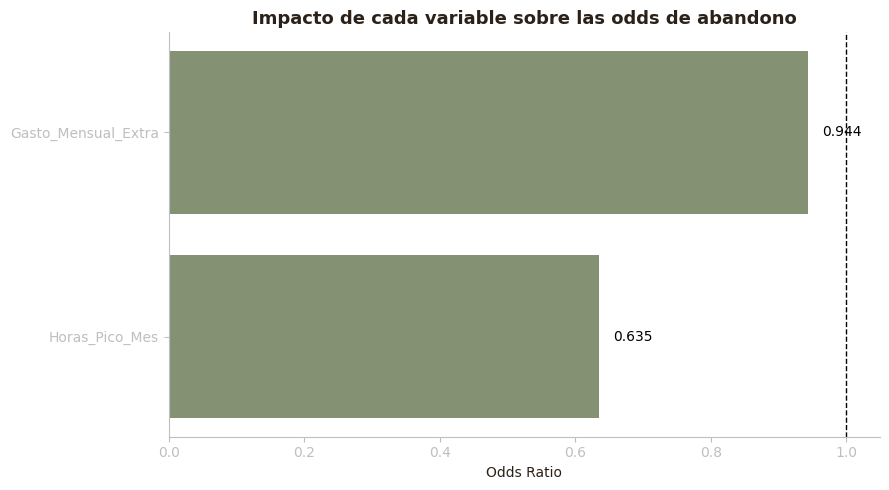

In [53]:
# Visualización de los Odds Ratios
fig, ax = plt.subplots(figsize=(9, 5))

tabla_plot = tabla_or.drop("const", errors="ignore").copy()
tabla_plot = tabla_plot.sort_values("Odds Ratio")

colores = [GREEN if v < 1 else RED for v in tabla_plot["Odds Ratio"]]

ax.barh(tabla_plot.index, tabla_plot["Odds Ratio"], color=colores, alpha=0.85)
ax.axvline(1, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Odds Ratio")
ax.set_title("Impacto de cada variable sobre las odds de abandono", fontsize=13, weight="bold")

for i, v in enumerate(tabla_plot["Odds Ratio"]):
    ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## Insights de negocio

### El hallazgo principal

El **nivel de uso del gimnasio** es el principal determinante del abandono. El modelo refinado, tras eliminar las variables con problemas severos de multicolinealidad, confirma que **las horas en franja pico y el gasto en servicios extra** son las dos señales más fiables para predecir qué clientes abandonarán. Ambas variables apuntan en la misma dirección: **más compromiso = menos abandono**.

### ¿Por qué un modelo refinado?

El modelo completo con 4 variables presentaba un **VIF extremo** (hasta 62.77), lo que impedía separar los efectos individuales de cada predictor. Al reducir a 2 variables, los coeficientes se estabilizan, los intervalos de confianza se estrechan y la interpretación gana fiabilidad — todo ello sin una pérdida relevante de capacidad predictiva.

### ¿Qué dicen los datos?

1. **Las horas en franja pico son la señal más clara.** Cada hora adicional en franja pico reduce las odds de abandono de forma significativa. Los clientes que entrenan en horarios populares están más integrados en la dinámica social del gimnasio, lo que refuerza su permanencia.

2. **El gasto extra complementa la señal de uso.** Los clientes que consumen servicios adicionales (entrenador personal, nutrición, clases premium) abandonan menos. Este gasto refleja un nivel de compromiso que va más allá de la simple asistencia.

3. **La antigüedad no protege.** Fue descartada del modelo por su nula significación estadística (p = 0.476). Un cliente de 2 años que deja de asistir es tan vulnerable como uno de 2 meses.

4. **Las asistencias mensuales son redundantes con las horas pico.** La correlación entre ambas (0.94) hacía imposible separar sus efectos. El modelo refinado las descarta porque `Horas_Pico_Mes` captura la misma información con mayor precisión estadística.

### Recomendaciones

**1. Sistema de alertas basado en horas de uso (impacto: alto, esfuerzo: bajo)**

Implementar un scoring continuo que detecte caídas en `Horas_Pico_Mes` y `Gasto_Mensual_Extra`. Un cliente que reduce sus horas en pico a la mitad debe activar una intervención automática (email, llamada, oferta de reactivación).

**2. Programas de engagement en franja pico (impacto: alto)**

Las horas pico no solo correlacionan con retención — son el contexto donde se genera comunidad. Clases grupales, retos y actividades sociales en esas franjas refuerzan el vínculo emocional con el gimnasio.

**3. Incentivar el gasto en servicios complementarios (impacto: medio)**

No porque gastar más fidelice directamente, sino porque el cliente que invierte en entrenador personal o nutrición tiene más razones para quedarse. Ofrecer pruebas gratuitas de servicios premium a clientes en riesgo puede ser una palanca de retención efectiva.

**4. Scoring de riesgo para priorizar recursos (impacto: estratégico)**

La regresión logística produce una **probabilidad continua** de abandono para cada cliente. No es lo mismo un cliente con 5% de riesgo que uno con 70%. El equipo de retención debe priorizar los casos con mayor probabilidad predicha, asignando recursos de forma proporcional al nivel de riesgo.